In [1]:
# Import pandas library for data handling and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Understanding

In [2]:
# Load the fraud detection dataset from the CSV file into a DataFrame
fraud_df = pd.read_csv("Fraud detection Dataset.csv")

### Dataset Shape & Size

In [3]:
# Check the shape of the dataset (rows, columns)
fraud_df.shape

(100186, 18)

In [4]:
# Return the total number of elements (rows × columns) in the dataset
fraud_df.size

1803348

In [5]:
# Display the first 5 rows of the dataset to understand the structure
fraud_df.head()

,transaction_id,user_id,transaction_amount,transaction_type,transaction_time,location,is_foreign_transaction,device_type,is_new_device,is_new_location,account_age_days,avg_transaction_amount,transactions_last_24h,failed_logins_24h,time_since_last_txn,txn_hour,is_weekend,is_fraud
0,T0086548,U9625,5068.33,NEFT,25-09-2024 02:47,Delhi,0,Tablet,0,1,3124,4957.53,1,0,947,2,0,0
1,T0088155,U9783,3428.09,IMPS,23-06-2024 07:32,Delhi,0,Mobile,0,1,2302,3750.88,0,0,902,7,1,0
2,T0076282,U8629,5161.81,NEFT,02-06-2024 16:01,Mumbai,0,Mobile,0,0,1157,4075.63,5,0,893,16,1,0
3,T0013138,U2319,4242.40,UPI,30-01-2024 01:36,Chennai,0,Tablet,0,0,613,3745.28,2,1,1139,1,0,0
4,T0060581,U7056,1721.96,UPI,02-07-2024 06:52,Hyderabad,0,Desktop,0,0,637,2818.78,1,0,710,6,0,0


In [6]:
# Display 5 random rows from the dataset
fraud_df.sample(n=5)

,transaction_id,user_id,transaction_amount,transaction_type,transaction_time,location,is_foreign_transaction,device_type,is_new_device,is_new_location,account_age_days,avg_transaction_amount,transactions_last_24h,failed_logins_24h,time_since_last_txn,txn_hour,is_weekend,is_fraud
17070,T0047712,U5762,5798.73,ATM Withdrawal,11-05-2024 22:36,Mumbai,0,Mobile,0,0,952,4860.91,1,0,822,22,1,0
82645,T0086321,U9602,3171.59,ATM Withdrawal,16-11-2024 10:57,Hyderabad,0,Desktop,0,0,2674,3266.29,2,1,512,10,1,0
68073,T0065972,U7594,1670.46,UPI,26-02-2024 00:17,Bangalore,0,Tablet,0,0,992,2464.35,0,1,143,0,0,0
9309,T0042065,U5198,9511.84,UPI,13-07-2024 04:35,Mumbai,0,Mobile,1,0,732,3736.02,3,0,793,4,1,1
707,T0060656,U7062,5804.49,UPI,29-07-2024 11:23,Bangalore,0,Mobile,0,0,2373,4224.08,1,0,38,11,0,0


In [7]:
# View column names and data types
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100186 entries, 0 to 100185
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   transaction_id          100186 non-null  object 
 1   user_id                 100186 non-null  object 
 2   transaction_amount      100186 non-null  float64
 3   transaction_type        100186 non-null  object 
 4   transaction_time        100186 non-null  object 
 5   location                100186 non-null  object 
 6   is_foreign_transaction  100186 non-null  int64  
 7   device_type             100186 non-null  object 
 8   is_new_device           100186 non-null  int64  
 9   is_new_location         100186 non-null  int64  
 10  account_age_days        100186 non-null  int64  
 11  avg_transaction_amount  100186 non-null  float64
 12  transactions_last_24h   100186 non-null  int64  
 13  failed_logins_24h       100186 non-null  int64  
 14  time_since_last_txn 

### Column Descriptions

| Column Name | Description |
|---|---|
| `transaction_id` | Unique identifier for each transaction |
| `user_id` | Unique identifier for each user/customer |
| `transaction_amount` | Amount involved in the transaction |
| `transaction_type` | Type of transaction (e.g., purchase, transfer, withdrawal) |
| `transaction_time` | Date and time when the transaction occurred |
| `location` | Geographic location where the transaction was made |
| `is_foreign_transaction` | Indicates whether the transaction was made internationally (1 = Yes, 0 = No) |
| `device_type` | Type of device used for the transaction |
| `is_new_device` | Indicates if the transaction was made using a new device (1 = Yes, 0 = No) |
| `is_new_location` | Indicates if the transaction was made from a new location (1 = Yes, 0 = No) |
| `account_age_days` | Number of days since the account was created |
| `avg_transaction_amount` | Average transaction amount of the user |
| `transactions_last_24h` | Total number of transactions made in the last 24 hours |
| `failed_logins_24h` | Number of failed login attempts in the last 24 hours |
| `time_since_last_txn` | Time elapsed since the previous transaction |
| `txn_hour` | Hour of the day when the transaction occurred |
| `is_weekend` | Indicates whether the transaction occurred on a weekend (1 = Yes, 0 = No) |
| `is_fraud` | Target variable indicating whether the transaction is fraudulent (1 = Fraud, 0 = Legitimate) |

### Missing Values

In [8]:
# Check for missing/null values in each column
fraud_df.isna().sum()

transaction_id            0
user_id                   0
transaction_amount        0
transaction_type          0
transaction_time          0
location                  0
is_foreign_transaction    0
device_type               0
is_new_device             0
is_new_location           0
account_age_days          0
avg_transaction_amount    0
transactions_last_24h     0
failed_logins_24h         0
time_since_last_txn       0
txn_hour                  0
is_weekend                0
is_fraud                  0
dtype: int64

***Note : All columns contain 0 missing/null values***

In [9]:
# Check for duplicate values
duplicated_count = fraud_df.duplicated().sum()
print(f"The number of duplicates: {duplicated_count}")

The number of duplicates: 0


***Strong Data Quality Indicator - No duplicate rows exist in the dataset.***

## Univariate Analysis

### Numerical Variable Analysis

| Column                   | Why Useful for Descriptive Stats             |
| ------------------------ | -------------------------------------------- |
| `transaction_amount`     | Understand spending behaviour and outliers   |
| `account_age_days`       | Analyze customer account maturity            |
| `avg_transaction_amount` | Compare normal vs unusual spending           |
| `transactions_last_24h`  | Detect high activity patterns                |
| `failed_logins_24h`      | Useful fraud/risk behaviour indicator        |
| `time_since_last_txn`    | Helps identify suspicious rapid transactions |
| `txn_hour`               | Analyze transaction timing patterns          |


In [10]:
# Generate basic statistical summary of numerical columns
num_cols = ['transaction_amount', 
            'account_age_days', 
            'avg_transaction_amount', 
            'transactions_last_24h', 
            'failed_logins_24h', 
            'time_since_last_txn', 
            'txn_hour']

fraud_df[num_cols].describe()

,transaction_amount,account_age_days,avg_transaction_amount,transactions_last_24h,failed_logins_24h,time_since_last_txn,txn_hour
count,100186.000000,100186.000000,100186.000000,100186.000000,100186.000000,100186.000000,100186.000000
mean,4048.520040,1853.048490,3999.466963,2.359611,0.402441,705.595203,11.345807
std,1669.796529,1026.607819,999.985467,2.395163,0.632826,422.794611,6.974852
min,10.000000,100.000000,218.970000,0.000000,0.000000,1.000000,0.000000
25%,3014.170000,961.000000,3314.240000,1.000000,0.000000,340.000000,5.000000
50%,4021.300000,1862.000000,3993.830000,2.000000,0.000000,706.000000,11.000000
75%,5029.347500,2738.000000,4675.400000,3.000000,1.000000,1070.000000,17.000000
max,18673.300000,3649.000000,8015.580000,19.000000,5.000000,1440.000000,23.000000


### Binary Variable Analysis

#### Step 1 — Select Binary Columns

In [11]:
# Binary columns (0 = No, 1 = Yes)
binary_cols = [
    'is_foreign_transaction',
    'is_new_device',
    'is_new_location',
    'is_weekend',
    'is_fraud'
]

#### Step 2 — Frequency Distribution

In [12]:
# Binary Variable Summary Table
for col in binary_cols:
    
    # Create summary table
    summary_df = pd.DataFrame({
        'Count': fraud_df[col].value_counts(),
        'Percentage (%)': round(fraud_df[col].value_counts(normalize=True) * 100, 2)
    })
    
    # Rename index values for readability
    summary_df.index = ['No (0)', 'Yes (1)']
    
    print(f"\n{'='*40}")
    print(f"Binary Variable Analysis: {col}")
    print(f"{'='*40}")
    
    display(summary_df)


Binary Variable Analysis: is_foreign_transaction


,Count,Percentage (%)
No (0),94190,94.02
Yes (1),5996,5.98



Binary Variable Analysis: is_new_device


,Count,Percentage (%)
No (0),90732,90.56
Yes (1),9454,9.44



Binary Variable Analysis: is_new_location


,Count,Percentage (%)
No (0),88414,88.25
Yes (1),11772,11.75



Binary Variable Analysis: is_weekend


,Count,Percentage (%)
No (0),72258,72.12
Yes (1),27928,27.88



Binary Variable Analysis: is_fraud


,Count,Percentage (%)
No (0),90168,90.0
Yes (1),10018,10.0


What to analyze ?

- Are foreign transactions rare? - Yes only ~6% of the total transcations
- Are fraud cases imbalanced? - Yes only 10% of the total transcations are Fraud
- Do most users transact on known devices? 
- Are frauds more common on weekends? 

#### Step 3 — Visualize Categories

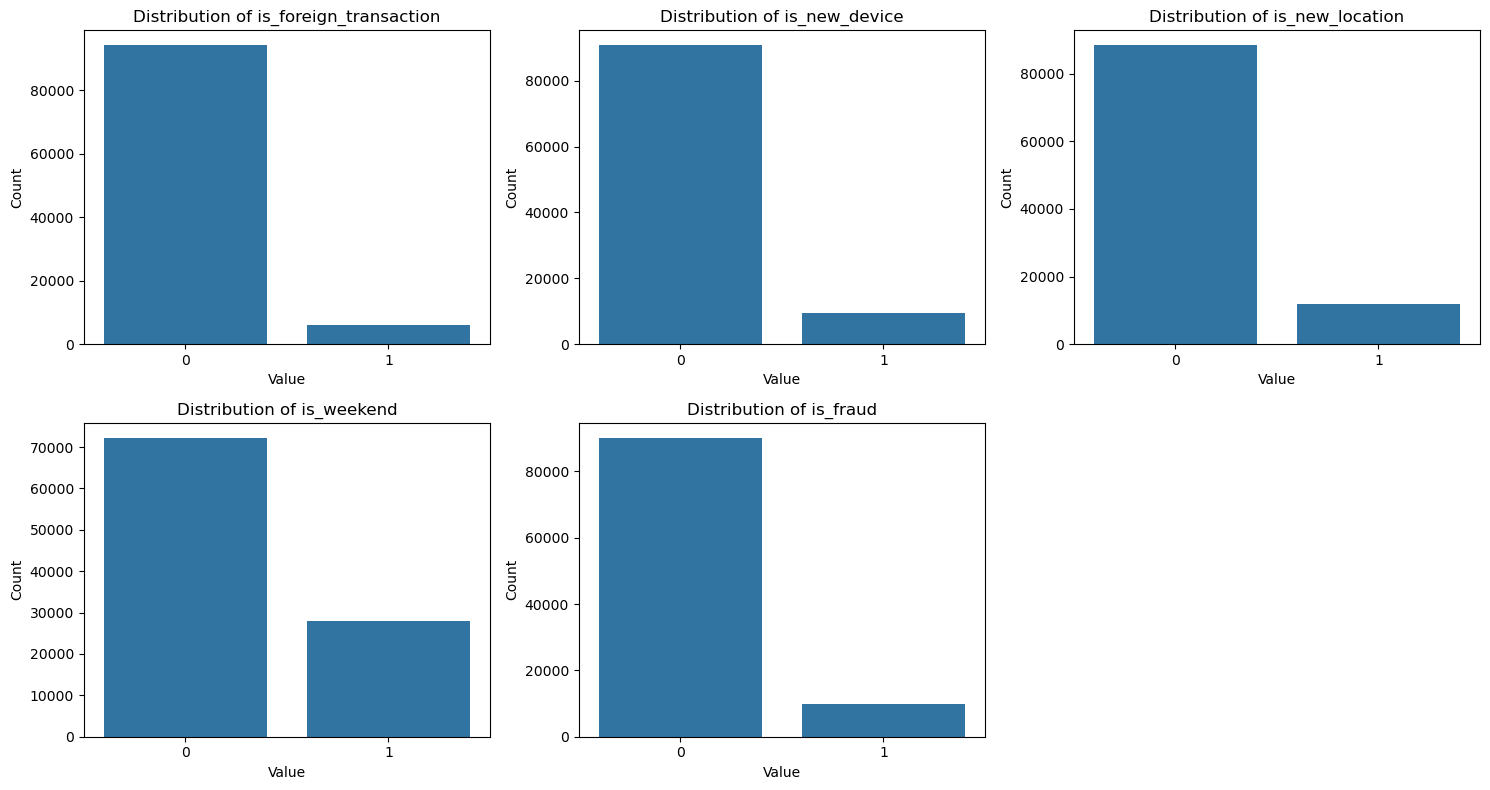

In [13]:
# Create subplot layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# Flatten axes array for easy looping
axes = axes.flatten()

# Loop through binary columns
for i, col in enumerate(binary_cols):
    
    sns.countplot(
        x=fraud_df[col],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

# Remove empty subplot if fewer than 6 plots
for j in range(len(binary_cols), len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing
plt.tight_layout()

# Show plots
plt.show()

In [14]:
# Compare fraud rate across binary variables

# Loop through all binary columns except the target column 'is_fraud'
# binary_cols[:-1] excludes the last column from the list
for col in binary_cols[:-1]:
    
    # Group data based on binary variable values (0 and 1)
    # Then calculate the mean fraud rate for each group
    # Mean works because:
    # 0 = Non-fraud
    # 1 = Fraud
    # So the average gives fraud percentage
    fraud_rate = fraud_df.groupby(col)['is_fraud'].mean() * 100
    
    # Display column name
    print(f"\nFraud Rate by {col}")
    
    # Display fraud percentages rounded to 2 decimal places
    print(round(fraud_rate, 2))


Fraud Rate by is_foreign_transaction
is_foreign_transaction
0     8.11
1    39.73
Name: is_fraud, dtype: float64

Fraud Rate by is_new_device
is_new_device
0     6.24
1    46.12
Name: is_fraud, dtype: float64

Fraud Rate by is_new_location
is_new_location
0     6.44
1    36.75
Name: is_fraud, dtype: float64

Fraud Rate by is_weekend
is_weekend
0    10.70
1     8.19
Name: is_fraud, dtype: float64


### Business Interpretation

- Transactions from new devices show higher fraud rates. - 46%
- Foreign transactions appear more risky compared to domestic transactions.
- Fraudulent transactions are more frequent in unfamiliar locations.

## Bivariate and Multivariate analysis

### Numerical vs Target Variable

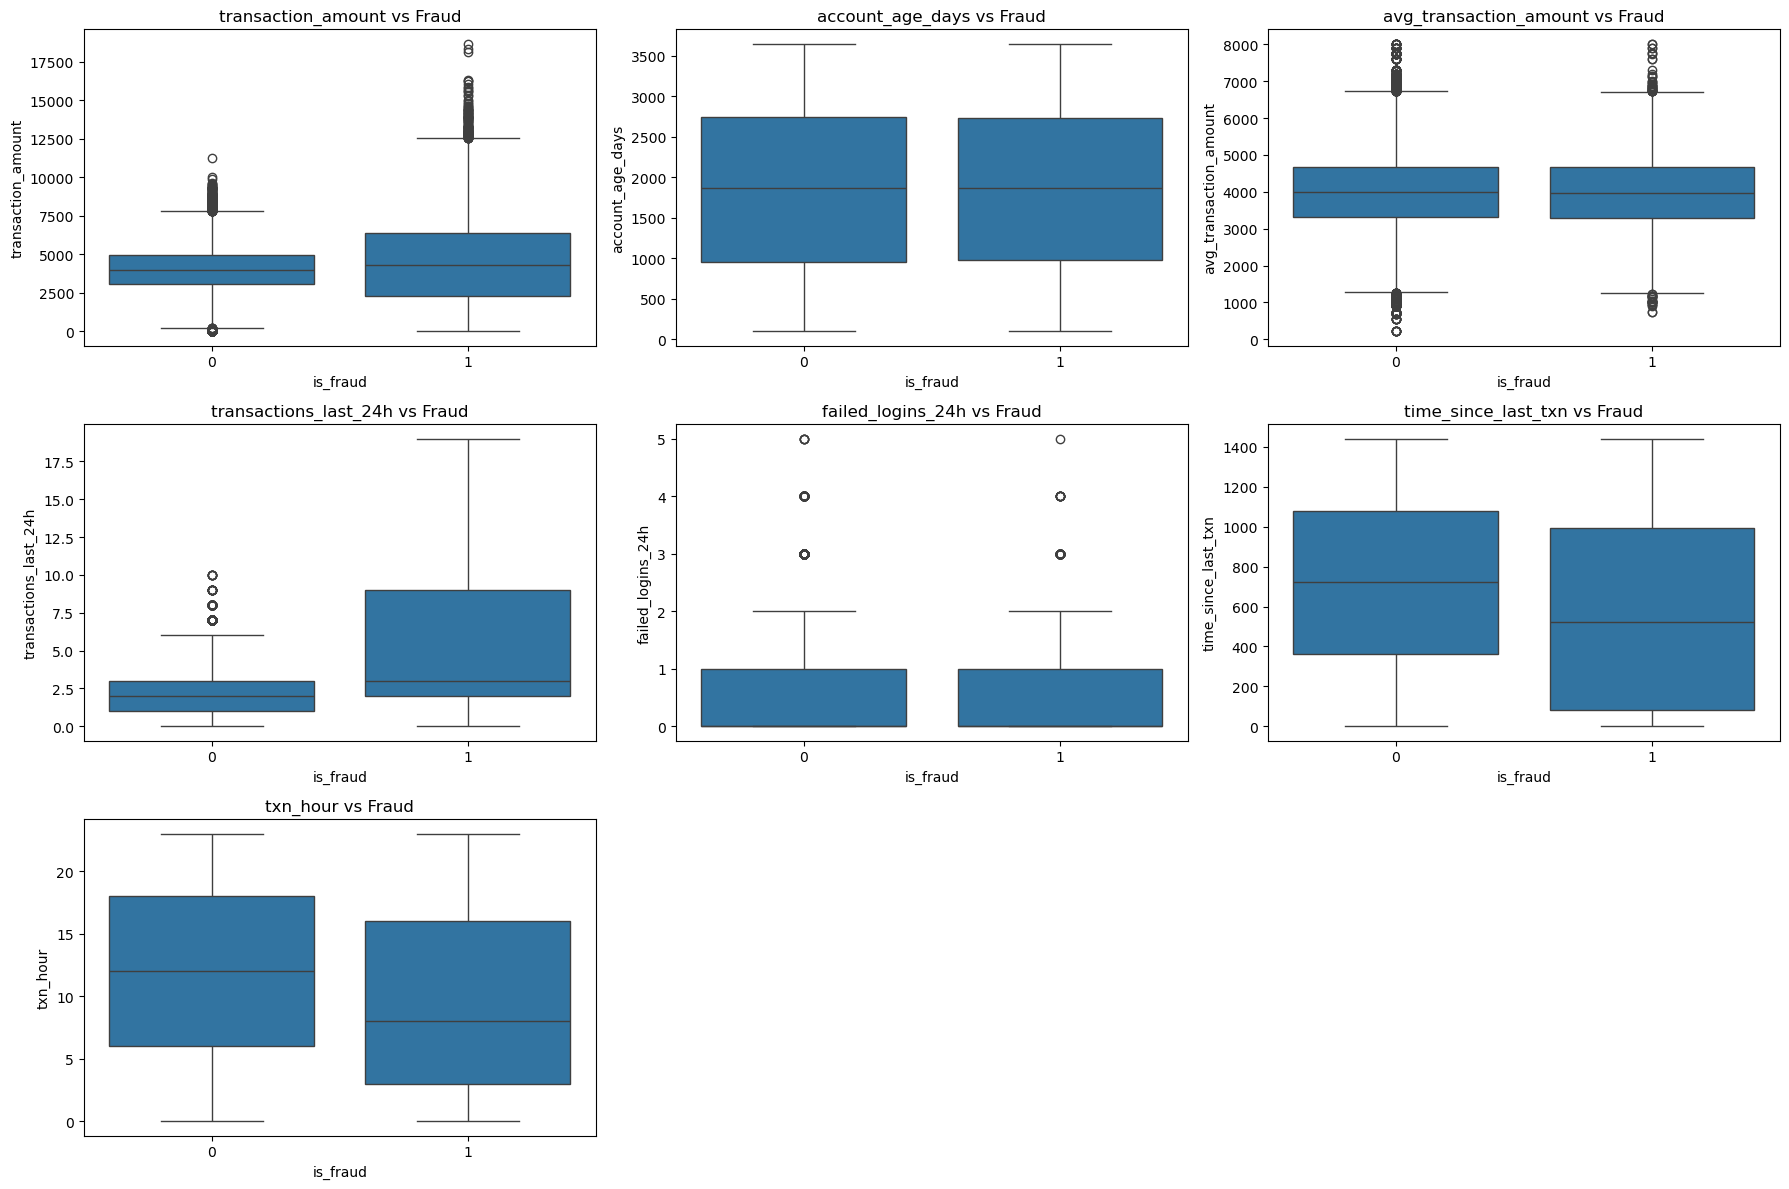

In [15]:
# Numerical columns
num_cols = [
    'transaction_amount',
    'account_age_days',
    'avg_transaction_amount',
    'transactions_last_24h',
    'failed_logins_24h',
    'time_since_last_txn',
    'txn_hour'
]

# Compare distributions using boxplots
plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols):
    
    plt.subplot(3, 3, i + 1)
    
    sns.boxplot(
        x='is_fraud',
        y=col,
        data=fraud_df
    )
    
    plt.title(f'{col} vs Fraud')

plt.tight_layout()
plt.show()

***Overall Key Insights***

Strong Potential Fraud Indicators

The following variables show noticeable behavioral differences between fraud and non-fraud transactions:

- transaction_amount
- transactions_last_24h
- failed_logins_24h
- time_since_last_txn
- txn_hour

These variables are likely to contribute significantly to machine learning model performance.

Variables with Weaker Separation

The following variables show limited visible separation:

- account_age_days
- avg_transaction_amount

Although weaker individually, they may still provide predictive value when combined with other features.

### Correlation Analysis

#### Correlation Heatmap

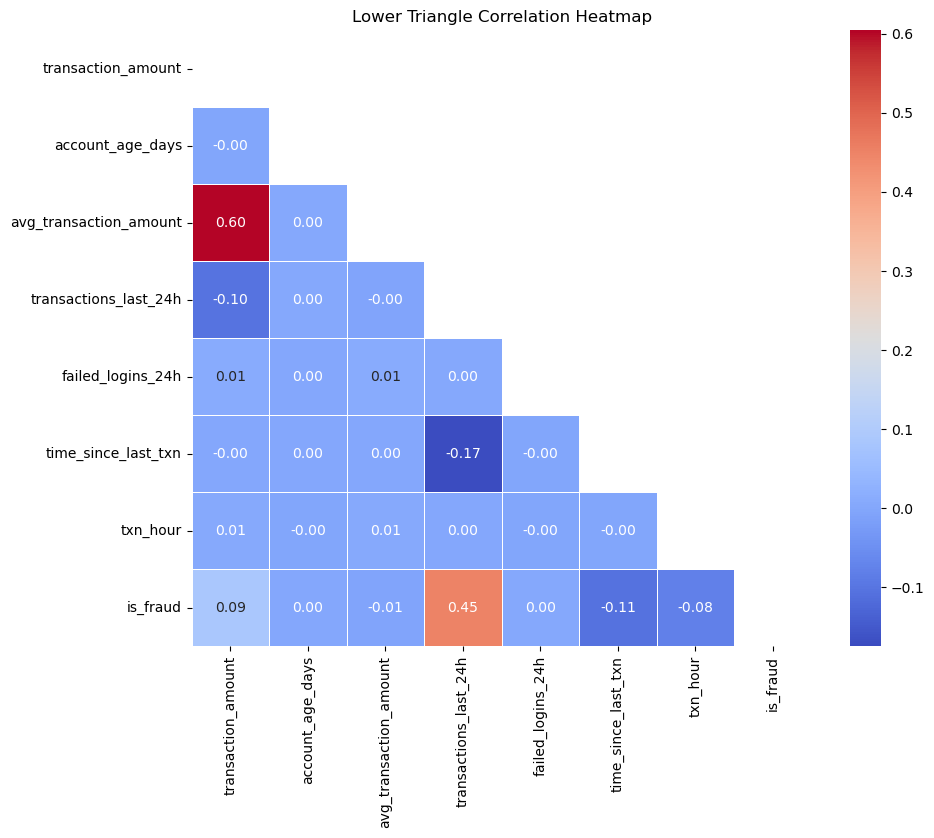

In [16]:
# Correlation matrix for numerical variables
corr_matrix = fraud_df[num_cols + ['is_fraud']].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,                 # Hide upper triangle
    annot=True,                # Show correlation values
    cmap='coolwarm',           # Color palette
    fmt='.2f',                 # Display values up to 2 decimals
    linewidths=0.5             # Add spacing between cells
)

# Add title
plt.title('Lower Triangle Correlation Heatmap')

# Display plot
plt.show()

### Key Correlation Insights

- `transactions_last_24h` shows the strongest positive correlation with fraud, indicating that rapid transaction activity is a major fraud indicator.
- `time_since_last_txn` has a negative relationship with fraud, suggesting fraudulent transactions tend to occur within shorter time intervals.
- Most variables demonstrate weak individual correlations with fraud, highlighting the complex and non-linear nature of fraudulent behaviour.
- `transaction_amount` and `avg_transaction_amount` show moderate positive correlation, indicating behavioural consistency in user spending patterns.

***The overall weak correlations suggest that advanced machine learning models capable of capturing non-linear interactions may perform better for fraud detection tasks***

### Pairplot

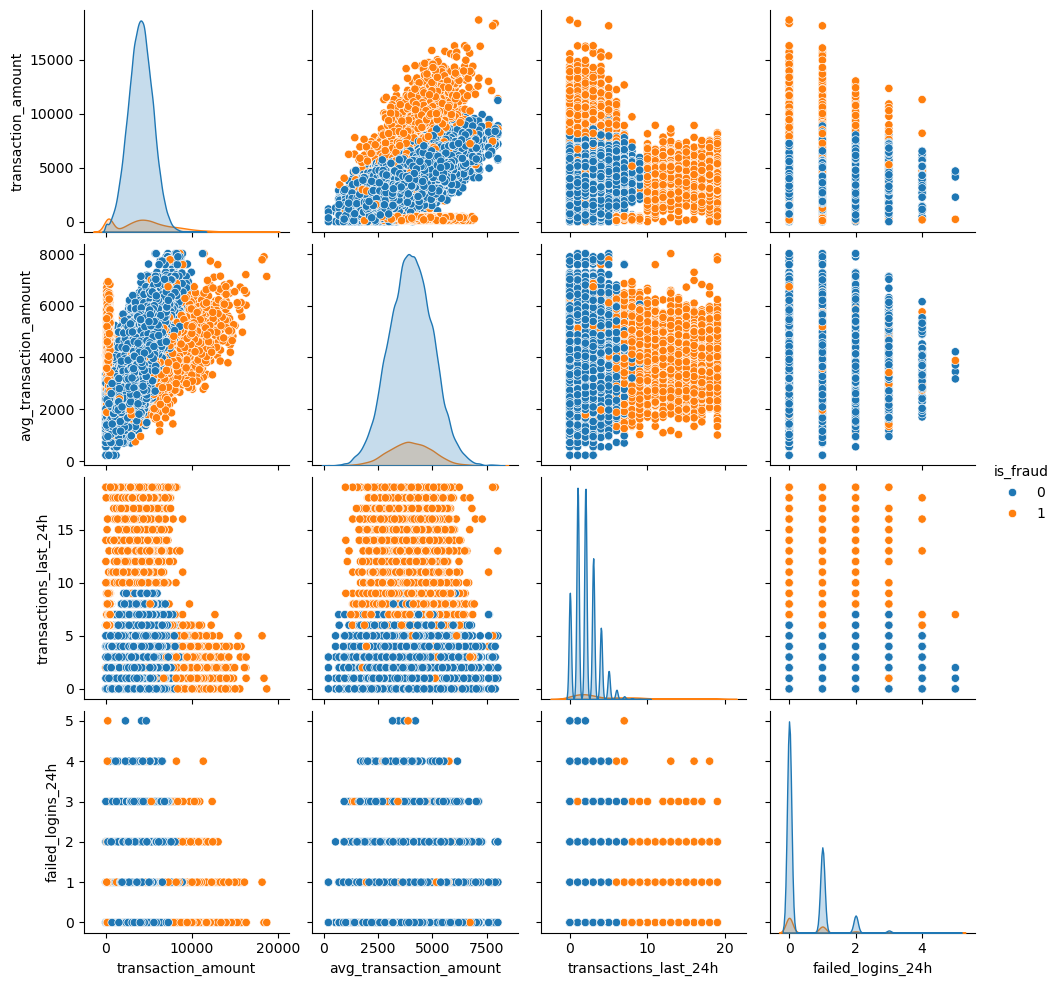

In [17]:
# Pairplot for key numerical variables
selected_cols = [
    'transaction_amount',
    'avg_transaction_amount',
    'transactions_last_24h',
    'failed_logins_24h',
    'is_fraud'
]

sns.pairplot(
    fraud_df[selected_cols],
    hue='is_fraud'
)

plt.show()

### Categorical vs Fraud Analysis

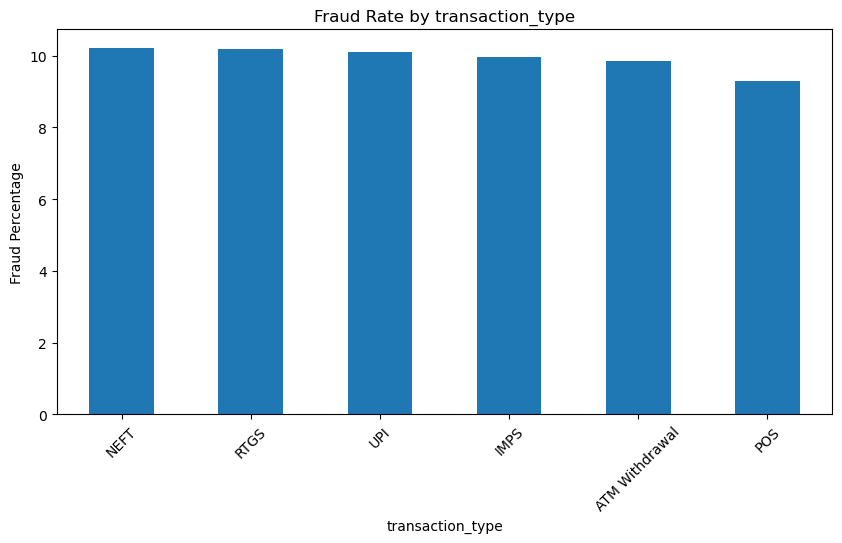

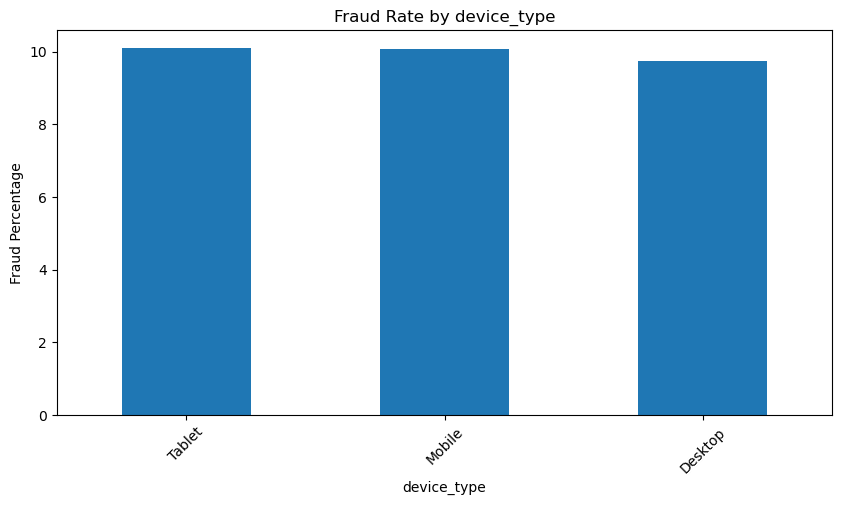

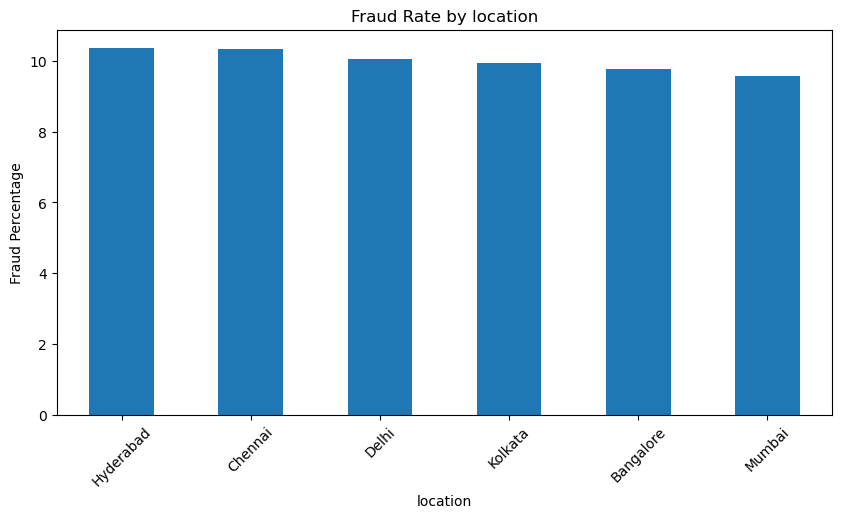

In [18]:
# Analyze fraud percentage across categorical variables

# List of categorical columns
categorical_cols = [
    'transaction_type',
    'device_type',
    'location'
]

# Loop through each categorical column
for col in categorical_cols:
    
    # Group data by category
    # Calculate average fraud rate for each category
    # Multiply by 100 to convert into percentage
    # Sort values in descending order
    fraud_rate = (
        fraud_df.groupby(col)['is_fraud']
        .mean()
        .sort_values(ascending=False) * 100
    )
    
    # Create figure size
    plt.figure(figsize=(10, 5))
    
    # Plot top 10 categories with highest fraud rates
    fraud_rate.head(10).plot(kind='bar')
    
    # Add chart title
    plt.title(f'Fraud Rate by {col}')
    
    # Label y-axis
    plt.ylabel('Fraud Percentage')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Display plot
    plt.show()

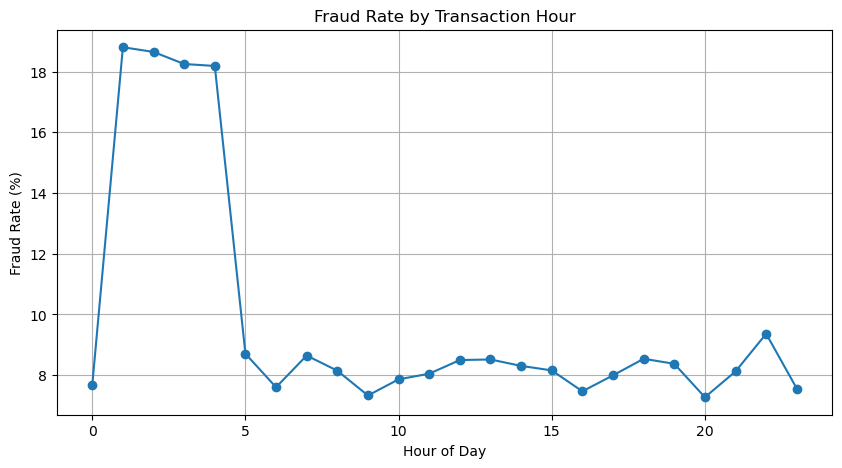

In [19]:
# Fraud trend across hours
hourly_fraud = fraud_df.groupby('txn_hour')['is_fraud'].mean() * 100

plt.figure(figsize=(10,5))

hourly_fraud.plot(marker='o')

plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')

plt.grid(True)
plt.show()

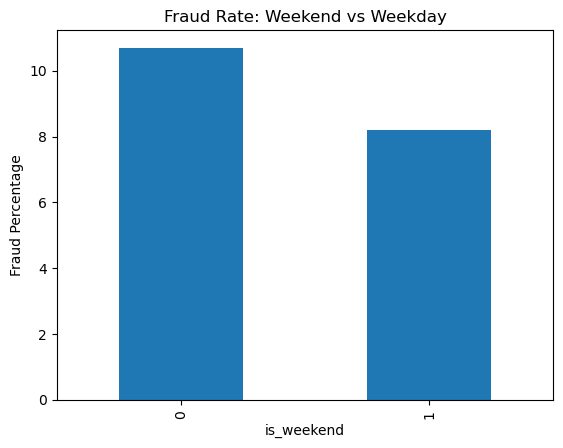

In [20]:
# Fraud rate on weekends vs weekdays
weekend_fraud = fraud_df.groupby('is_weekend')['is_fraud'].mean() * 100

weekend_fraud.plot(kind='bar')

plt.title('Fraud Rate: Weekend vs Weekday')
plt.ylabel('Fraud Percentage')

plt.show()

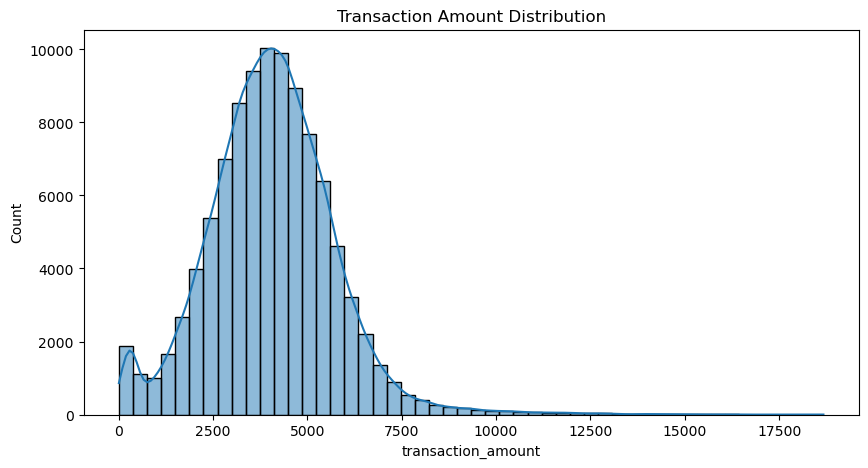

In [21]:
# Distribution of transaction amounts
plt.figure(figsize=(10,5))

sns.histplot(
    fraud_df['transaction_amount'],
    bins=50,
    kde=True
)

plt.title('Transaction Amount Distribution')
plt.show()

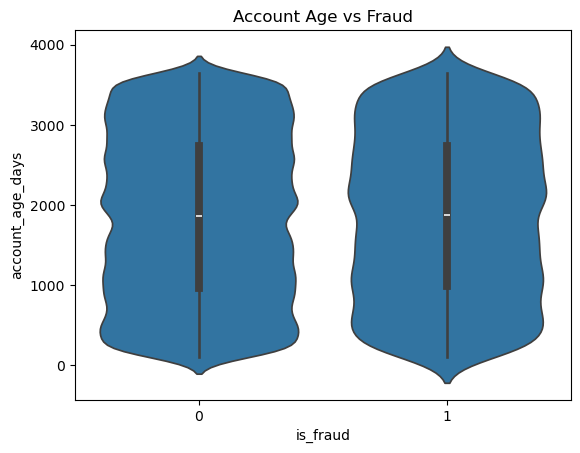

In [22]:
# Account age comparison
sns.violinplot(
    x='is_fraud',
    y='account_age_days',
    data=fraud_df
)

plt.title('Account Age vs Fraud')
plt.show()

## Fraud Detection Workflow

### STEP 1 — Feature Engineering

#### Transaction Deviation Feature

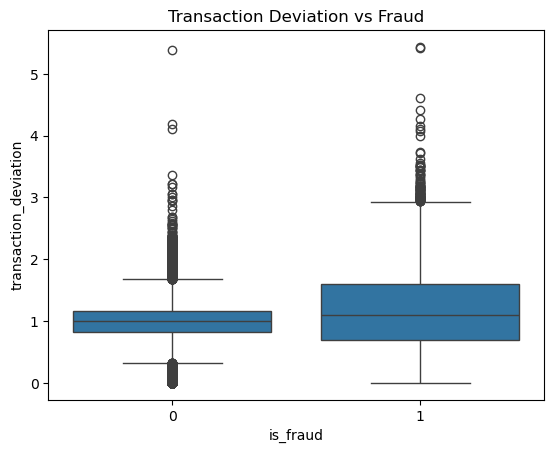

In [23]:
# Create a new feature to measure spending deviation
# This compares the current transaction amount with the user's average transaction amount
# Higher values may indicate unusual or suspicious spending behaviour

fraud_df['transaction_deviation'] = (
    fraud_df['transaction_amount'] /
    fraud_df['avg_transaction_amount']
)

# Create a boxplot to compare transaction deviation
# between fraudulent and non-fraudulent transactions

sns.boxplot(
    x='is_fraud',                    # Fraud status (0 = Legitimate, 1 = Fraud)
    y='transaction_deviation',       # Engineered feature
    data=fraud_df
)

# Add chart title
plt.title('Transaction Deviation vs Fraud')

# Display plot
plt.show()

feature has separation power - “Is the current transaction unusually larger than the user’s normal spending?”

- fraud deviation much higher
- legitimate deviation tightly clustered

#### Transaction Frequency Feature

In [24]:
# Average transaction frequency per hour
fraud_df['txn_per_hour'] = (
    fraud_df['transactions_last_24h'] / 24
)

#### Rapid Transaction Indicator

In [25]:
# Flag rapid transactions
fraud_df['rapid_txn_flag'] = (
    fraud_df['time_since_last_txn'] < 60
).astype(int)

In [26]:
# Fraud rate for rapid transactions
fraud_df.groupby('rapid_txn_flag')['is_fraud'].mean() * 100

rapid_txn_flag
0     8.116604
1    39.445275
Name: is_fraud, dtype: float64

##### Interpretation

Transactions occurring rapidly show much higher fraud rates.

#### High Risk Login Activity

In [27]:
# Flag suspicious login activity
fraud_df['high_failed_login'] = (
    fraud_df['failed_logins_24h'] >= 3
).astype(int)


#### Night Transaction Flag

In [28]:
# Transactions during unusual hours
fraud_df['night_transaction'] = (
    fraud_df['txn_hour'].between(0, 5)
).astype(int)

### STEP 2 — Encode Categorical Variables

Machine learning models need numbers.

In [29]:
# Encode categorical variables
fraud_df_encoded = pd.get_dummies(
    fraud_df,
    columns=[
        'transaction_type',
        'device_type',
        'location'
    ],
    drop_first=True
)

### STEP 3 — Drop Unnecessary Columns

IDs usually don’t help prediction.

In [30]:
# Drop identifier columns
fraud_df_encoded.drop(
    ['transaction_id', 'user_id', 'transaction_time'],
    axis=1,
    inplace=True
)

### STEP 4 — Define Features & Target

In [31]:
# Features
X = fraud_df_encoded.drop('is_fraud', axis=1)

# Target variable
y = fraud_df_encoded['is_fraud']

### STEP 5 — Train/Test Split

Fraud datasets are imbalanced.

Example:

- 98% non-fraud & 2% fraud
- Stratification preserves class proportions.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### STEP 6 — Scale Numerical Features

In [33]:
from sklearn.preprocessing import StandardScaler

# Logistic Regression is sensitive to feature scale, but one-hot/binary flags
# should stay as 0/1 indicators. Scale only continuous numeric features.
continuous_features = [
    'transaction_amount',
    'account_age_days',
    'avg_transaction_amount',
    'transactions_last_24h',
    'failed_logins_24h',
    'time_since_last_txn',
    'txn_hour',
    'transaction_deviation',
    'txn_per_hour'
]

scaler = StandardScaler()

X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

X_train_lr[continuous_features] = scaler.fit_transform(X_train_lr[continuous_features])
X_test_lr[continuous_features] = scaler.transform(X_test_lr[continuous_features])


#### Model 1 — Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' helps the model pay more attention to fraud cases,
# which are the minority class in this dataset.
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_lr, y_train)

y_pred_lr = lr_model.predict(X_test_lr)
y_prob_lr = lr_model.predict_proba(X_test_lr)[:, 1]


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """Return the main fraud-detection metrics for one model."""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob)
    }

lr_results = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))


              precision    recall  f1-score   support

  Legitimate       0.98      0.87      0.92     18034
       Fraud       0.43      0.85      0.57      2004

    accuracy                           0.87     20038
   macro avg       0.70      0.86      0.75     20038
weighted avg       0.93      0.87      0.89     20038



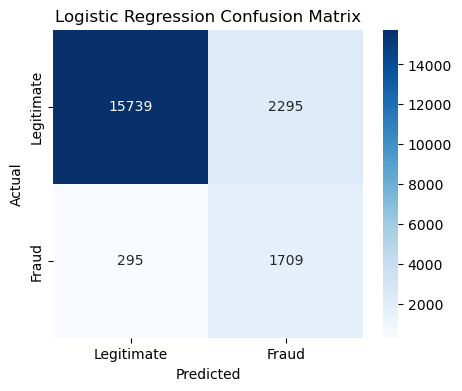

In [36]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### Model 2 — Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


In [38]:
rf_results = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)

print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))


              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99     18034
       Fraud       0.99      0.77      0.87      2004

    accuracy                           0.98     20038
   macro avg       0.98      0.89      0.93     20038
weighted avg       0.98      0.98      0.98     20038



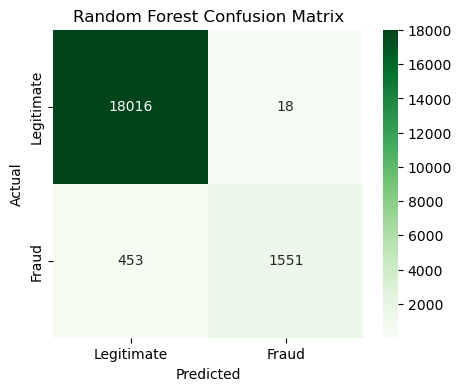

In [39]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### STEP 9 — Model Comparison

For fraud detection, the most important metric depends on business cost:

- **Recall** tells us how many actual fraud cases the model catches.
- **Precision** tells us how many flagged transactions are truly fraud.
- **F1 Score** balances precision and recall.
- **ROC-AUC** measures general ranking ability across thresholds.
- **PR-AUC** is especially useful when fraud is rare because it focuses on the positive fraud class.


In [40]:
# Compare both models in one table
model_results = pd.DataFrame([lr_results, rf_results])

model_results.set_index('Model').round(4)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.8707,0.4268,0.8528,0.5689,0.9490,0.7336
Random Forest,0.9765,0.9885,0.7740,0.8682,0.9864,0.9230


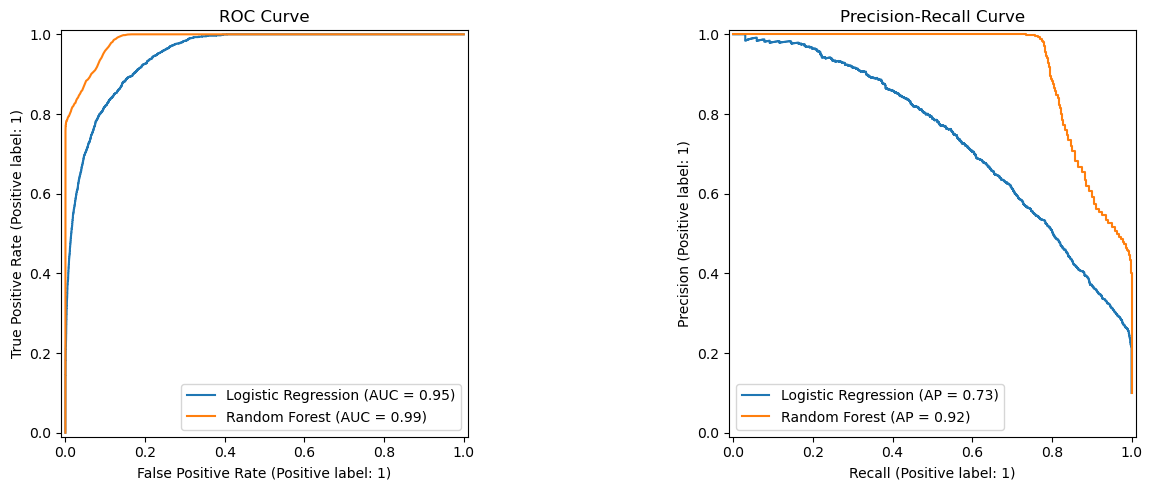

In [41]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name='Logistic Regression',
    ax=axes[0]
)
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name='Random Forest',
    ax=axes[0]
)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name='Logistic Regression',
    ax=axes[1]
)
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name='Random Forest',
    ax=axes[1]
)
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


### STEP 10 — Feature Importance

Random Forest can show which variables contributed most strongly to its decisions. This does not prove causation, but it helps explain which patterns the model found useful.


/var/folders/7f/3s2chqx942sfr2r40nb5vhww0000gn/T/ipykernel_36855/3341279228.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


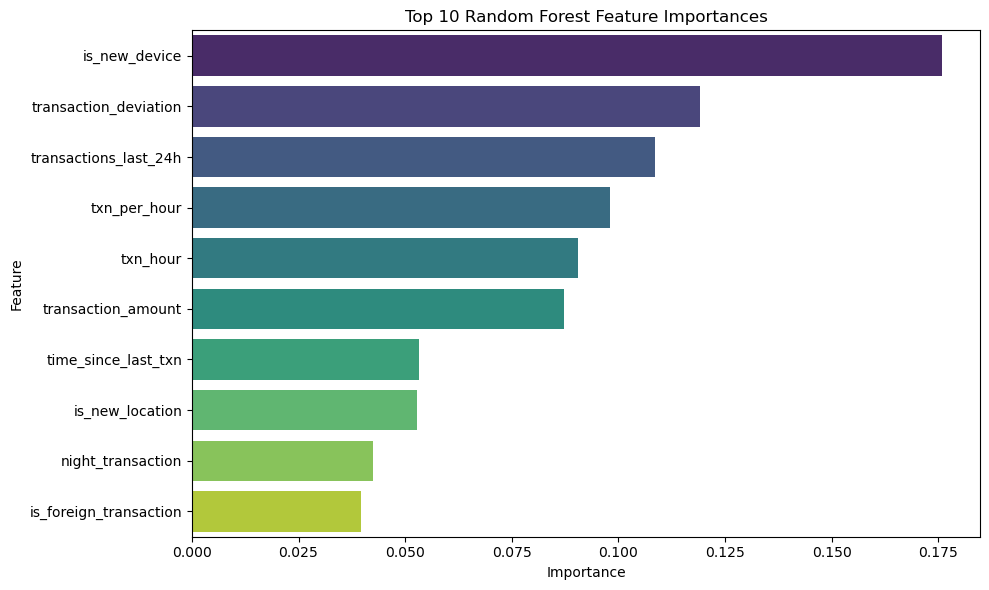

,Feature,Importance
2,is_new_device,0.175970
11,transaction_deviation,0.119136
6,transactions_last_24h,0.108521
12,txn_per_hour,0.098095
9,txn_hour,0.090513
0,transaction_amount,0.087204
8,time_since_last_txn,0.053346
3,is_new_location,0.052822
15,night_transaction,0.042462
1,is_foreign_transaction,0.039584


In [42]:
# Extract and visualize feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df.head(10)


## Final Conclusion

This notebook builds a fraud detection workflow from raw transaction data to model evaluation. The dataset is imbalanced, with fraud representing about 10% of all transactions, so evaluation should focus on fraud-class recall, precision, F1 score, ROC-AUC, and PR-AUC rather than accuracy alone.

The analysis suggests that fraud is associated with unusual transaction behavior, especially transaction amount deviation, recent transaction frequency, failed login activity, new-device behavior, and timing/location signals.

Between the two baseline models, Logistic Regression provides an interpretable benchmark, while Random Forest captures more complex non-linear patterns and provides useful feature importance values. The preferred model should be selected based on business cost: catching more fraud usually means accepting more false alarms, while reducing false alarms may miss some fraud cases.
